# Lab 1: Getting Started with Data and AI — SOLUTION
## MPS311/439 — Machine Learning

This notebook contains working code and indicative answers. Student observations may use different wording when they match the output.

## Setup

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

DATA_URL = "https://raw.githubusercontent.com/wayXing/mps311-439-course-materials/main/lecture-slids/lessons/lesson1/lab/bike_rentals.csv"
df = pd.read_csv(DATA_URL)

print("Dataset loaded successfully.")
print("Rows and columns:", df.shape)

Dataset loaded successfully.
Rows and columns: (337, 9)


In [2]:
message = "My Lesson 1 notebook is working."
print(message)

My Lesson 1 notebook is working.


## Part 1: Meet the dataset

In [3]:
df.head()

,date,day,hour,temperature_c,humidity_pct,wind_speed_kmh,weather,is_weekend,rentals
0,2025-09-15,Monday,0,10.2,76.0,4.6,Clear,0,24
1,2025-09-15,Monday,1,8.3,75.0,6.2,Clear,0,4
2,2025-09-15,Monday,2,11.0,71.0,4.6,Clear,0,25
3,2025-09-15,Monday,3,11.8,70.0,5.6,Clear,0,25
4,2025-09-15,Monday,4,11.8,77.0,7.0,Clear,0,10


One row represents the weather conditions and number of bicycle rentals during one hour.

In [4]:
print("Rows and columns:", df.shape)
print("Column names:", df.columns.tolist())

Rows and columns: (337, 9)
Column names: ['date', 'day', 'hour', 'temperature_c', 'humidity_pct', 'wind_speed_kmh', 'weather', 'is_weekend', 'rentals']


## Part 2: Inspect the data

In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 337 entries, 0 to 336
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            337 non-null    object 
 1   day             337 non-null    object 
 2   hour            337 non-null    int64  
 3   temperature_c   336 non-null    float64
 4   humidity_pct    336 non-null    float64
 5   wind_speed_kmh  336 non-null    float64
 6   weather         337 non-null    object 
 7   is_weekend      337 non-null    int64  
 8   rentals         337 non-null    int64  
dtypes: float64(3), int64(3), object(3)
memory usage: 23.8+ KB


,hour,temperature_c,humidity_pct,wind_speed_kmh,is_weekend,rentals
count,337.000000,336.000000,336.000000,336.000000,337.000000,337.000000
mean,11.465875,14.010417,71.571429,8.111905,0.287834,60.525223
std,6.950475,4.537826,7.751800,2.066082,0.453427,47.577194
min,0.000000,4.000000,56.000000,4.500000,0.000000,4.000000
25%,5.000000,10.075000,66.000000,6.475000,0.000000,10.000000
50%,11.000000,13.900000,71.000000,8.150000,0.000000,58.000000
75%,17.000000,18.025000,76.000000,9.800000,1.000000,97.000000
max,23.000000,23.300000,94.000000,12.700000,1.000000,162.000000


The non-null counts show missing entries in `temperature_c`, `humidity_pct`, and `wind_speed_kmh`. The exact minimum, mean, and maximum for `rentals` appear in the summary above; the maximum should be larger than the mean and minimum.

## Part 3: Check data quality and use AI

In [6]:
missing_values = df.isna().sum()
print(missing_values)

duplicate_rows = df.duplicated().sum()
print("Duplicate rows:", duplicate_rows)

date              0
day               0
hour              0
temperature_c     1
humidity_pct      1
wind_speed_kmh    1
weather           0
is_weekend        0
rentals           0
dtype: int64
Duplicate rows: 1


In [7]:
df_clean = df.drop_duplicates().dropna().copy()

print("Original shape:", df.shape)
print("Clean shape:   ", df_clean.shape)

Original shape: (337, 9)
Clean shape:    (333, 9)


The worksheet intentionally uses `weather_type`, which does not exist. The smallest correction is to use the actual column name `weather`. Successful output should list counts for Clear, Cloudy, and Rain.

In [8]:
df_clean["weather"].value_counts()

weather
Clear     180
Cloudy    113
Rain       40
Name: count, dtype: int64

## Part 4: Make three simple plots

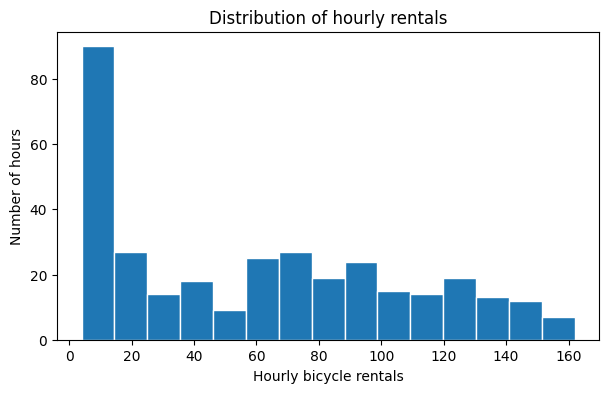

In [9]:
plt.figure(figsize=(7, 4))
plt.hist(df_clean["rentals"], bins=15, edgecolor="white")
plt.xlabel("Hourly bicycle rentals")
plt.ylabel("Number of hours")
plt.title("Distribution of hourly rentals")
plt.show()

Most hours lie toward the lower-to-middle part of the rental range, while a smaller number of hours have very high demand.

weather
Clear     72.138889
Cloudy    55.654867
Rain      22.725000
Name: rentals, dtype: float64


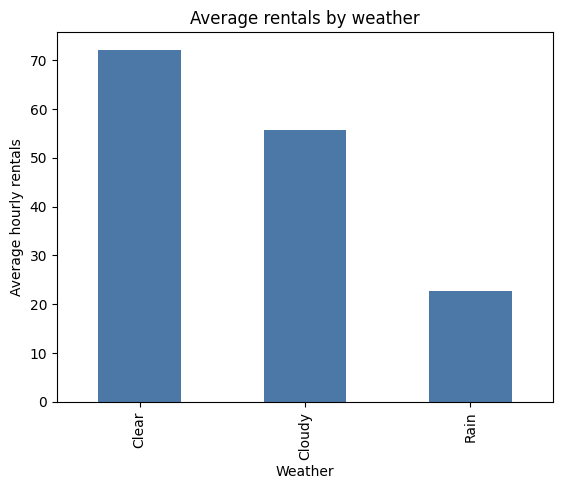

In [10]:
rentals_by_weather = df_clean.groupby("weather")["rentals"].mean()
print(rentals_by_weather)

rentals_by_weather.plot(kind="bar", color="#4C78A8")
plt.xlabel("Weather")
plt.ylabel("Average hourly rentals")
plt.title("Average rentals by weather")
plt.show()

Clear weather has the highest average rentals in this dataset.

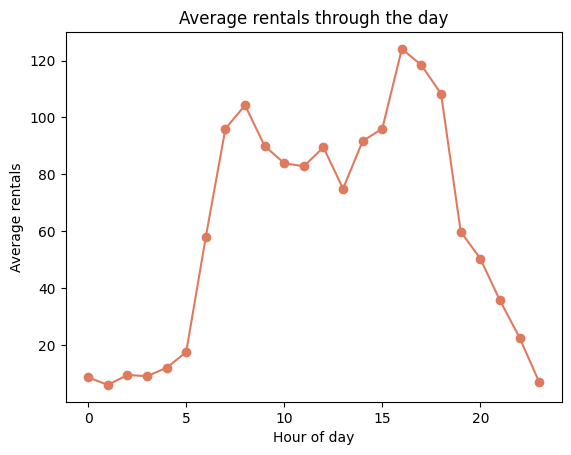

In [11]:
rentals_by_hour = df_clean.groupby("hour")["rentals"].mean()

rentals_by_hour.plot(kind="line", marker="o", color="#E07A5F")
plt.xlabel("Hour of day")
plt.ylabel("Average rentals")
plt.title("Average rentals through the day")
plt.show()

The hourly plot has morning and late-afternoon peaks. A suitable final reflection is: the data show that bicycle rentals vary strongly across the day. AI helped diagnose a column-name error by comparing the requested name with the actual columns.

# Advanced Study — reference investigations

All three options have illustrative answers below. Other datasets, plots and conclusions are valid when supported by checks. AI prompts and audit examples are teaching examples, not a transcript of an actual student conversation. Students should record their own checks and revisions.


## Breadth A


            count       mean
is_weekend                  
0             237  59.645570
1              96  62.989583
is_weekend           0       1
hour                          
0             8.000000   10.50
1             5.800000    6.75
2            10.200000    8.00
3             9.200000    9.00
4            12.000000   12.25
5            16.500000   20.50
6            65.800000   38.75
7           108.600000   64.75
8           113.900000   80.25
9            96.444444   75.50
10           76.700000  102.00
11           68.600000  118.50
12           82.000000  108.25
13           52.900000  130.25
14           71.300000  142.75
15           76.200000  145.75
16          129.666667  111.50
17          139.200000   66.25
18          120.300000   78.25
19           65.800000   45.25
20           46.800000   59.50
21           34.400000   39.25
22           20.900000   27.25
23            5.555556   10.75


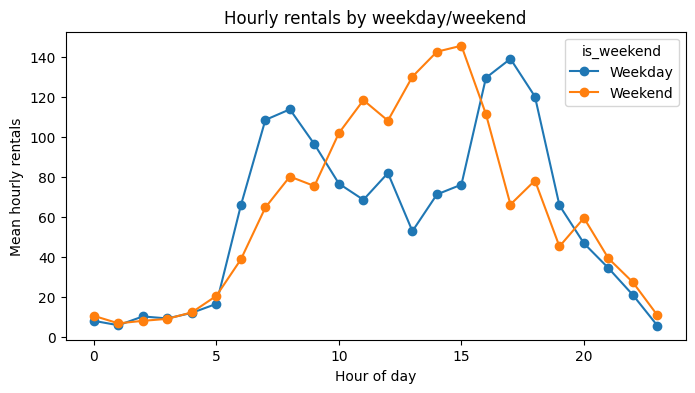

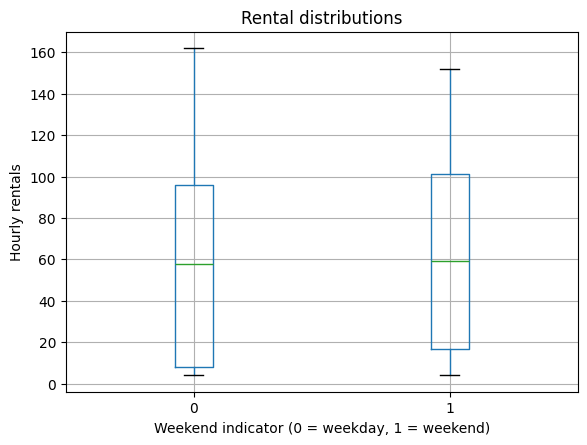

Checked weekday 08:00 mean: 113.9


In [12]:
print(df_clean.groupby("is_weekend")["rentals"].agg(["count", "mean"]))
hourly = df_clean.groupby(["hour", "is_weekend"])["rentals"].mean().unstack()
print(hourly)
hourly.rename(columns={0: "Weekday", 1: "Weekend"}).plot(marker="o", figsize=(8,4))
plt.xlabel("Hour of day")
plt.ylabel("Mean hourly rentals")
plt.title("Hourly rentals by weekday/weekend")
plt.show()
df_clean.boxplot(column="rentals", by="is_weekend")
plt.xlabel("Weekend indicator (0 = weekday, 1 = weekend)")
plt.ylabel("Hourly rentals")
plt.title("Rental distributions")
plt.suptitle("")
plt.show()
print("Checked weekday 08:00 mean:", df_clean.loc[(df_clean.hour == 8) & (df_clean.is_weekend == 0), "rentals"].mean())


The mean curve compares timing; the box plot compares spread. Check the printed weekday 08:00 mean against the corresponding point. Weekday commuting peaks and weekend timing differ in this synthetic dataset; these observations do not establish real-world demand. A useful revision separates the two curves into panels with shared axes when overlap makes reading difficult.


### Breadth A: example follow-up and audit

**Illustrative follow-up:** “The curves overlap. Put weekdays and weekends in separate panels with the same y-axis limits so I can compare timing without hiding the magnitude difference.”

Check that 0 is labelled Weekday and 1 Weekend, group by both hour and is_weekend before averaging, and compare the printed weekday 08:00 value with its plotted point. Shared axes matter: separately autoscaled panels can exaggerate apparent similarity. These are suggested audit steps; students should report the checks they actually performed.


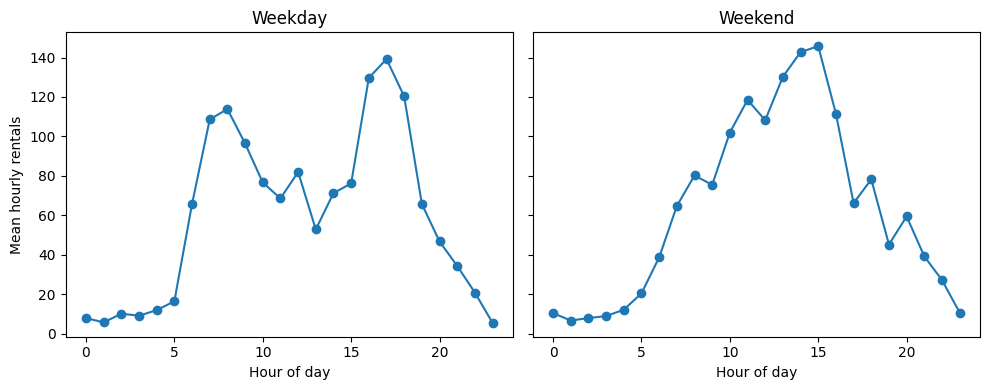

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
for ax, group_code, label in zip(axes, [0, 1], ["Weekday", "Weekend"]):
    ax.plot(hourly.index, hourly[group_code], marker="o")
    ax.set_title(label)
    ax.set_xlabel("Hour of day")
axes[0].set_ylabel("Mean hourly rentals")
fig.tight_layout()
plt.show()


## Breadth B: A worked Kaggle investigation — Iris

**Dataset selection:** [Kaggle Iris Species](https://www.kaggle.com/datasets/uciml/iris); original documentation: [UCI Iris](https://archive.ics.uci.edu/dataset/53/iris). Kaggle's [official download tutorial](https://github.com/Kaggle/kaggle-cli/blob/main/docs/tutorials.md) uses this dataset and identifies `Iris.csv`. This small dataset is suitable because its measurements and species labels are documented. It is a worked example; students may choose another topic.

**Download route:** open the Kaggle page, download the data (sign in if requested), unzip it, and upload `Iris.csv` through Colab **Files → Upload**. The cell below reads that file if present; otherwise it downloads the same public Kaggle archive so this reference notebook can be run without a manual upload. It reads only the CSV, not the SQLite file.

**Question:** How do petal length and petal width differ among the three species in these recorded flowers?

**Observation and units:** one row is one flower observation. Lengths and widths are in centimetres. `Id` identifies a record; it is not a biological measurement.

**Illustrative AI prompt:**

> My DataFrame `iris` has Id, SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm, Species. One row is a flower; measurements are in cm. Compare petal measurements across species using a box plot and a scatter plot. Print group counts and summary statistics, use existing columns, and do not invent conclusions before seeing outputs.



In [14]:
from pathlib import Path
import io
import urllib.request
import zipfile

if Path("Iris.csv").exists():
    iris = pd.read_csv("Iris.csv")
else:
    iris_url = "https://www.kaggle.com/api/v1/datasets/download/uciml/iris"
    with urllib.request.urlopen(iris_url, timeout=60) as response:
        archive_bytes = response.read()
    with zipfile.ZipFile(io.BytesIO(archive_bytes)) as archive:
        iris = pd.read_csv(archive.open("Iris.csv"))
print("Shape:", iris.shape)
print(iris.dtypes)
print("Missing entries:\n", iris.isna().sum())
print("Duplicate rows:", iris.duplicated().sum())
print(iris.head())
print(iris.groupby("Species")["PetalLengthCm"].agg(["count", "mean", "min", "max"]))


Shape: (150, 6)
Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object
Missing entries:
 Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64
Duplicate rows: 0
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
                 count   mean  min  max
Species                                
Iris-setosa         50  1.464  1.0  1.9
Iris-versicolor     50  4.260  3.0  5.1
Iris-virginica      50  5.552  4.5 

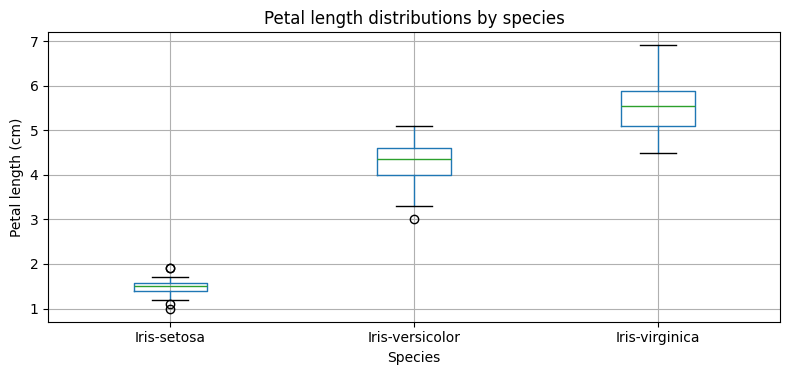

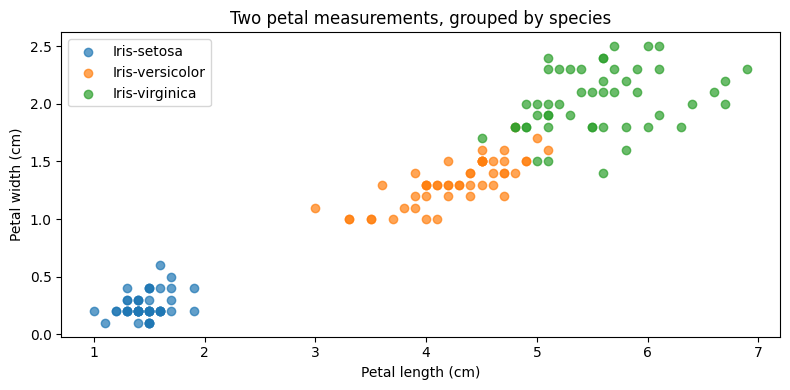

Checked setosa count: 50
Checked setosa mean petal length (cm): 1.464
Checked setosa median petal length (cm): 1.5


In [15]:
iris.boxplot(column="PetalLengthCm", by="Species", figsize=(8, 4))
plt.xlabel("Species")
plt.ylabel("Petal length (cm)")
plt.title("Petal length distributions by species")
plt.suptitle("")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
for species, group in iris.groupby("Species"):
    ax.scatter(group["PetalLengthCm"], group["PetalWidthCm"], label=species, alpha=0.7)
ax.set_xlabel("Petal length (cm)")
ax.set_ylabel("Petal width (cm)")
ax.set_title("Two petal measurements, grouped by species")
ax.legend()
fig.tight_layout()
plt.show()

checked = iris.loc[iris.Species == "Iris-setosa", "PetalLengthCm"]
print("Checked setosa count:", len(checked))
print("Checked setosa mean petal length (cm):", checked.sum() / len(checked))
print("Checked setosa median petal length (cm):", checked.median())


### Reference investigation record

**Question and choice:** I compared petal measurements across species. The box plot shows within-species spread; the scatter plot shows the relationship between two measurements and where groups overlap.

**Evidence and check:** there are 150 rows, 50 per species, and no missing entries. Mean petal lengths are approximately 1.464 cm (setosa), 4.260 cm (versicolor), and 5.552 cm (virginica). The independently calculated setosa mean matches the summary. Its median is 1.5 cm, matching the box plot's median line; the mean is not the box's central line.

**Illustrative AI revision:** if AI initially suggests a bar chart of means, ask: “Replace the mean bar chart with a box plot so I can inspect spread. Colour the scatter by Species and omit Id from the measurements.” This is an example of a useful revision, not a claim that AI always makes that error.

**Conclusion:** setosa has shorter and narrower petals in these observations, while versicolor and virginica overlap in the two-measurement view. These graphs describe this sample; they do not prove a causal explanation or guarantee perfect identification of new flowers.

**Limit:** the data contain equal counts of the three species, which does not establish their proportions in nature. No predictive model or held-out evaluation was performed.



## Depth C


In [16]:
dedup = df.drop_duplicates()
needed = dedup.dropna(subset=["weather", "rentals"]).copy()
print("All-column cleaning rows:", len(df_clean))
print("Question-specific cleaning rows:", len(needed))
print(pd.concat({"all_columns": df_clean.groupby("weather")["rentals"].agg(["count", "mean"]), "needed_columns": needed.groupby("weather")["rentals"].agg(["count", "mean"])}, axis=1))
print(needed.groupby(["weather", "is_weekend"])["rentals"].agg(["count", "mean"]))
print("Checked Clear mean:", needed.loc[needed.weather == "Clear", "rentals"].mean())


All-column cleaning rows: 333
Question-specific cleaning rows: 336
        all_columns            needed_columns           
              count       mean          count       mean
weather                                                 
Clear           180  72.138889            181  72.530387
Cloudy          113  55.654867            113  55.654867
Rain             40  22.725000             42  23.095238
                    count       mean
weather is_weekend                  
Clear   0             124  73.354839
        1              57  70.736842
Cloudy  0              81  54.432099
        1              32  58.750000
Rain    0              35  23.857143
        1               7  19.285714
Checked Clear mean: 72.5303867403315


For this comparison, missing temperature, humidity or wind does not make the observed weather or rentals unusable. Question-specific cleaning retains those records. Report any numerical differences rather than assuming cleaning changes the ordering. Describe associations in this dataset; weekday/weekend grouping does not control every other difference, and synthetic observations cannot establish a causal weather effect. For an analysis involving temperature, the required-variable rule would change.

## Core interpretation update

The mean summarises central demand but cannot represent both the observed minimum and maximum; the range shows variation. One hour is the observational unit. All conclusions here describe synthetic teaching data.
